In [1]:
# K-Means Fundamentals

In [2]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (7,5)
np.random.seed(42)

In [3]:
# Dataset

#Two datasets used to build intuition:
#Synthetic blobs — known ground-truth clusters, ideal for seeing how K-Means and the elbow method behave.
#Iris dataset — real data, no ground-truth cluster labels used during fitting (labels only used later to sanity-check).

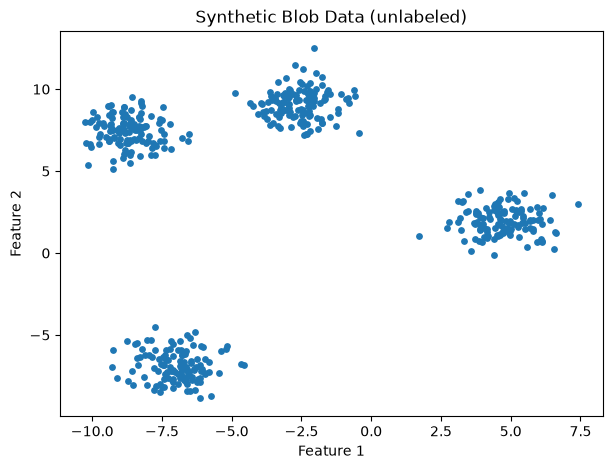

In [4]:
# Synthetic blobs: 4 well-separated clusters
X_blob, y_blob_true = make_blobs(n_samples=500, centers=4, cluster_std=0.9, random_state=42)

plt.scatter(X_blob[:,0], X_blob[:,1], s=15)
plt.title("Synthetic Blob Data (unlabeled)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()

In [5]:
# Real dataset: Iris (using 2 features for visualization simplicity)
iris = load_iris()
X_iris = iris.data
feature_names = iris.feature_names
df_iris = pd.DataFrame(X_iris, columns=feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
# Scale Iris features (K-Means is distance-based, scaling matters)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
X_iris_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [7]:
# Fit K-Means on Blob Data (K known = 4)

kmeans_blob = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_blob = kmeans_blob.fit_predict(X_blob)

print("Inertia:", kmeans_blob.inertia_)
print("Cluster centers:\n", kmeans_blob.cluster_centers_)

Inertia: 768.6011781034999
Cluster centers:
 [[ 4.71362999  1.92878701]
 [-8.69721653  7.44225918]
 [-6.98883113 -6.90202274]
 [-2.59291363  9.08462016]]


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


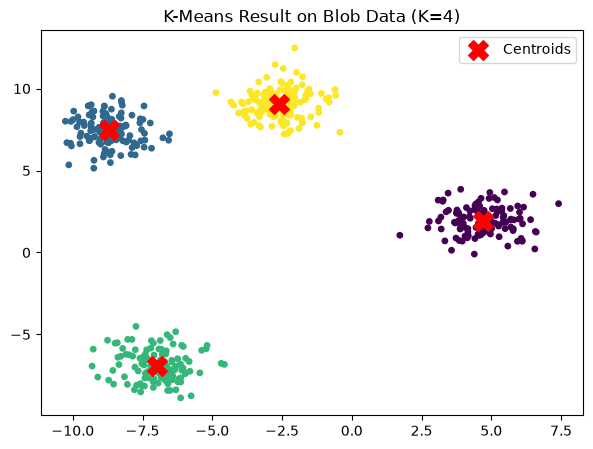

In [8]:
plt.scatter(X_blob[:,0], X_blob[:,1], c=labels_blob, cmap='viridis', s=15)
plt.scatter(kmeans_blob.cluster_centers_[:,0], kmeans_blob.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Result on Blob Data (K=4)")
plt.legend()
plt.show()

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\sit

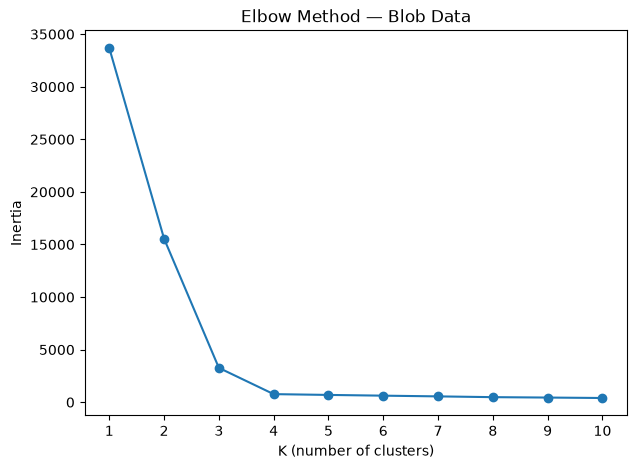

In [9]:
# Elbow Method — Choosing K

def elbow_data(X, k_range):
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    return inertias

k_range = range(1, 11)
inertias_blob = elbow_data(X_blob, k_range)

plt.plot(list(k_range), inertias_blob, marker='o')
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Blob Data")
plt.xticks(list(k_range))
plt.show()

c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\sit

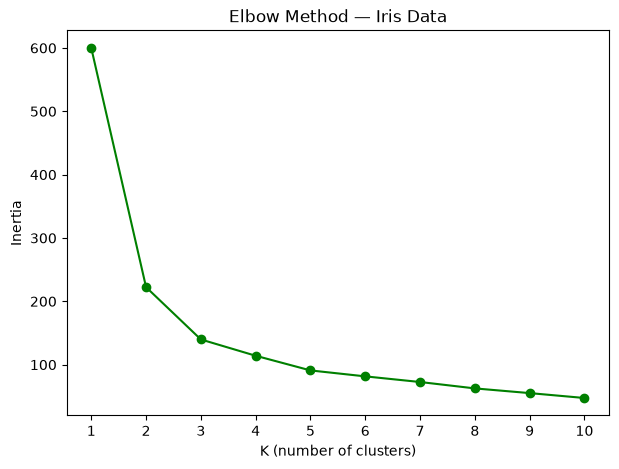

In [10]:
# Same elbow analysis on Iris (scaled)
inertias_iris = elbow_data(X_iris_scaled, k_range)

plt.plot(list(k_range), inertias_iris, marker='o', color='green')
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Iris Data")
plt.xticks(list(k_range))
plt.show()

Inertia (K=3): 139.82049635974982


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


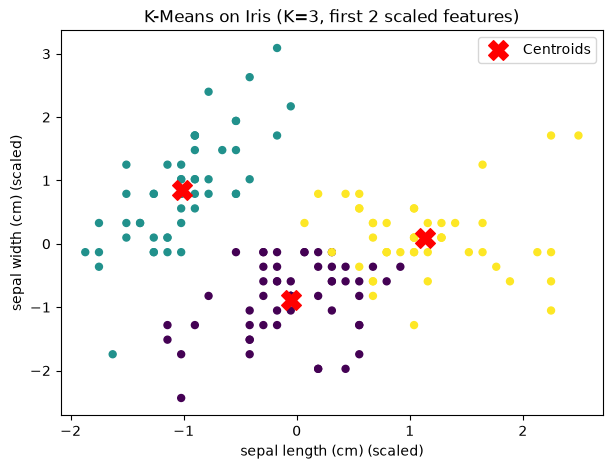

In [11]:
# Fit Final K-Means on Iris (K=3)

kmeans_iris = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_iris = kmeans_iris.fit_predict(X_iris_scaled)

print("Inertia (K=3):", kmeans_iris.inertia_)

plt.scatter(X_iris_scaled[:,0], X_iris_scaled[:,1], c=labels_iris, cmap='viridis', s=25)
plt.scatter(kmeans_iris.cluster_centers_[:,0], kmeans_iris.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("K-Means on Iris (K=3, first 2 scaled features)")
plt.legend()
plt.show()

In [12]:
# Sanity check: compare cluster assignment vs true species (not used during fitting)
comparison = pd.DataFrame({'cluster': labels_iris, 'true_species': iris.target})
pd.crosstab(comparison['cluster'], comparison['true_species'])

true_species,0,1,2
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36
